In [21]:
import pandas as pd

# Load the data from stimuli_search.csv into a pandas DataFrame
df = pd.read_csv('/content/stimuli_search.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,trial,condition,set_size,target_present,item_index,x,y,colour,shape,is_target
0,1,colour,9,yes,0,0.2935,1.4610,blue,circle,no
1,1,colour,9,yes,1,0.2649,2.3593,blue,circle,no
2,1,colour,9,yes,2,1.5027,2.2633,blue,circle,no
3,1,colour,9,yes,3,1.3494,1.5749,blue,circle,no
4,1,colour,9,yes,4,2.5225,2.3602,blue,circle,no


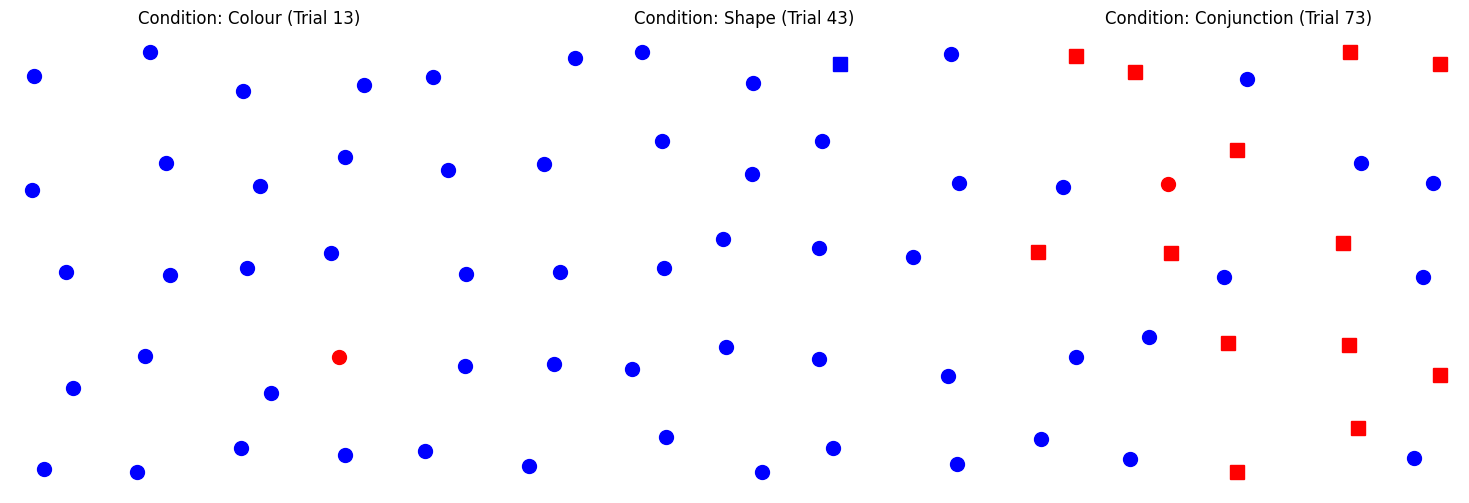

In [22]:
import matplotlib.pyplot as plt

def draw_trial(trial_num, ax):
    trial_data = df[df['trial'] == trial_num]
    ax.set_aspect('equal', adjustable='box')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    shape_map = {'circle': 'o', 'square': 's'}
    color_map = {'red': 'red', 'blue': 'blue'}

    for _, item in trial_data.iterrows():
        marker = shape_map.get(item['shape'], 'o') # Default to circle if shape is unknown
        color = color_map.get(item['colour'], 'black') # Default to black if color is unknown

        # Use a slightly larger size for visibility, adjust as needed
        ax.plot(item['x'], item['y'], marker=marker, color=color, markersize=10, linestyle='None')


# Find example trials for verification
colour_trial = df[(df['condition'] == 'colour') & (df['set_size'] == 25) & (df['target_present'] == 'yes')]['trial'].iloc[0]
shape_trial = df[(df['condition'] == 'shape') & (df['set_size'] == 25) & (df['target_present'] == 'yes')]['trial'].iloc[0]
conjunction_trial = df[(df['condition'] == 'conjunction') & (df['set_size'] == 25) & (df['target_present'] == 'yes')]['trial'].iloc[0]

# Create a 1x3 figure to display these trials
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Draw each trial on its respective subplot
draw_trial(colour_trial, axes[0])
axes[0].set_title(f'Condition: Colour (Trial {colour_trial})')

draw_trial(shape_trial, axes[1])
axes[1].set_title(f'Condition: Shape (Trial {shape_trial})')

draw_trial(conjunction_trial, axes[2])
axes[2].set_title(f'Condition: Conjunction (Trial {conjunction_trial})')

plt.tight_layout()
plt.show()

In [23]:
import pandas as pd

# Load the data for Gestalt principles from stimuli_gestalt.csv into a new pandas DataFrame
gestalt_df = pd.read_csv('/content/stimuli_gestalt.csv')

# Display the first few rows of the new DataFrame to inspect its structure
display(gestalt_df.head())

,panel,group,x,y,colour,shape,size,connector
0,proximity,g0,1.5130,1.6220,grey,circle,60,none
1,proximity,g0,1.2277,0.8682,grey,circle,60,none
2,proximity,g0,0.8520,0.0809,grey,circle,60,none
3,proximity,g0,0.6835,0.9270,grey,circle,60,none
4,proximity,g0,0.4485,1.3725,grey,circle,60,none


In [24]:
import pandas as pd

# Load the channel_trials.csv into a pandas DataFrame
channel_df = pd.read_csv('/content/channel_trials.csv')

# Display the first 5 rows to inspect the data
display(channel_df.head())

,trial,channel,true_ratio,value_large,value_small,reader_estimate,absolute_error
0,1,position,0.15,76,11.40,NaN,NaN
1,2,position,0.25,59,14.75,NaN,NaN
2,3,position,0.40,76,30.40,NaN,NaN
3,4,position,0.55,68,37.40,NaN,NaN
4,5,position,0.70,61,42.70,NaN,NaN


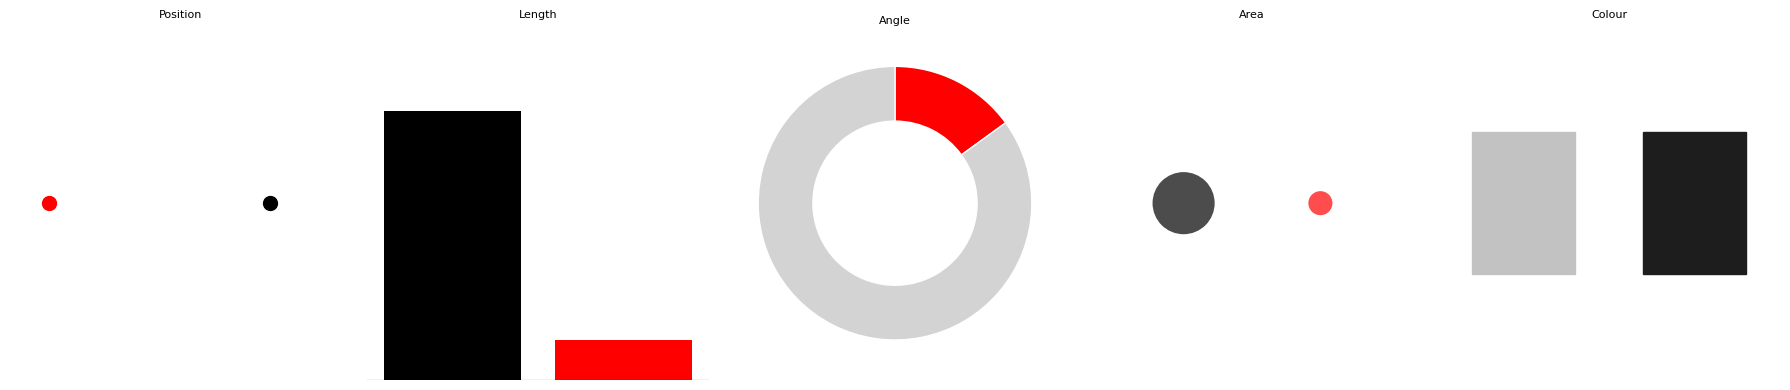

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Define a simple grayscale colormap for the 'colour' channel
colors = [(1, 1, 1), (0, 0, 0)] # White to Black
cm_gray = LinearSegmentedColormap.from_list("gray_gradient", colors, N=256)

def setup_ax(ax, title=""):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    ax.set_title(title, fontsize=8)

def plot_position(ax, value_large, value_small):
    setup_ax(ax, "Position")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 1)
    ax.plot(value_large, 0.5, 'o', color='black', markersize=10)
    ax.plot(value_small, 0.5, 'o', color='red', markersize=10)

def plot_length(ax, value_large, value_small):
    setup_ax(ax, "Length")
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(0, 100) # Assuming values are within this range
    ax.bar([0, 1], [value_large, value_small], color=['black', 'red'], width=0.8)
    ax.axhline(0, color='black', linewidth=0.8) # Common zero baseline

def plot_angle(ax, value_large, value_small):
    setup_ax(ax, "Angle")
    # For pie charts, it's easier to work with ratios. `value_small` as a percentage of `value_large`
    # The remaining part of the circle will be `value_large - value_small`
    values = [value_small, value_large - value_small] if value_large > value_small else [value_large, value_small - value_large]
    colors = ['red', 'lightgrey']
    if value_small > value_large:
        colors = ['lightgrey', 'red']
    wedges, _ = ax.pie(values, colors=colors, startangle=90, counterclock=False, wedgeprops=dict(width=0.4, edgecolor='w'))

def plot_area(ax, value_large, value_small):
    setup_ax(ax, "Area")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # `s` in scatter is area. So we pass the value directly.
    # Scale down the values for better visualization if they are too large
    scale_factor = 2000 / max(value_large, value_small) # Adjust max dot size to be around 2000
    ax.scatter(0.3, 0.5, s=value_large * scale_factor, color='black', alpha=0.7, edgecolors='none', label='Large')
    ax.scatter(0.7, 0.5, s=value_small * scale_factor, color='red', alpha=0.7, edgecolors='none', label='Small')

def plot_colour(ax, value_large, value_small):
    setup_ax(ax, "Colour")
    # Normalize values to 0-1 for colormap, assuming max value is 100 for simplicity
    norm_large = value_large / 100.0
    norm_small = value_small / 100.0

    # Use a sequential lightness ramp. Higher value should be lighter (or vice-versa)
    # Let's map higher values to darker colors (lower lightness value) for better contrast on white background
    # Or, map higher values to lighter colors (higher lightness value) if we think of ink.
    # Using 1 - norm_value to get darker for larger values
    ax.add_patch(plt.Rectangle((0.1, 0.3), 0.3, 0.4, color=cm_gray(1 - norm_large)))
    ax.add_patch(plt.Rectangle((0.6, 0.3), 0.3, 0.4, color=cm_gray(1 - norm_small)))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

# Example usage: display one trial for each channel
# Get the first trial's values for demonstration
example_trial = channel_df.iloc[0]
val_large = example_trial['value_large']
val_small = example_trial['value_small']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

plot_position(axes[0], val_large, val_small)
plot_length(axes[1], val_large, val_small)
plot_angle(axes[2], val_large, val_small)
plot_area(axes[3], val_large, val_small)
plot_colour(axes[4], val_large, val_small)

plt.tight_layout()
plt.show()